# SA-1 · Regresión: predicción de carreras (`runs`) a partir de turnos al bate (`bateos`)

**Dataset:** `beisbol.csv` · **Algoritmo:** Random Forest Regressor
**Materia:** Extracción de Conocimiento en Bases de Datos · **Alumno:** Irving Chaparro Peña

## 1. Justificación del algoritmo

El dataset contiene 30 equipos de béisbol con dos variables numéricas relevantes: `bateos` (turnos al bate) y `runs` (carreras anotadas), la variable objetivo. La columna `equipos` es un identificador con cardinalidad casi igual al número de filas (30 equipos distintos en 30 filas), por lo que no aporta señal generalizable y se descarta como feature.

En clase ya se trabajó este mismo dataset con **regresión lineal y regresión Ridge** (ver `regresion lineal 2-Optimización.ipynb` y `regresion ridge-Optimización.ipynb`). Para este ejercicio (SA, "algoritmo de tu preferencia") se eligió un algoritmo **no lineal y de ensamble, Random Forest Regressor**, para:

- Contrastar con los modelos lineales ya vistos y evaluar si existe una relación no lineal entre `bateos` y `runs`.
- Aprovechar la robustez de un ensamble de árboles ante el ruido, dado que el dataset es muy pequeño (30 observaciones).
- Tener un algoritmo con varios hiperparámetros relevantes (`n_estimators`, `max_depth`, `min_samples_leaf`) que permita demostrar una búsqueda de hiperparámetros no trivial.

**Limitación reconocida:** con solo 30 observaciones y un único predictor, un Random Forest puede sobreajustar más fácilmente que un modelo lineal; esto se discute en la sección de evaluación.

## 2. Diseño del modelo — paso a paso

1. Carga y exploración del dataset.
2. Gráfica de dispersión del comportamiento de los datos (`bateos` vs `runs`).
3. División train/test.
4. Modelo baseline (Random Forest con hiperparámetros por defecto).
5. Búsqueda de hiperparámetros con `GridSearchCV` (validación cruzada).
6. Evaluación del modelo optimizado (R², MAE, RMSE) comparado contra el baseline.
7. Gráfica de valores reales vs. predichos.
8. Importancia de la variable predictora.
9. Guardado del modelo final.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../datasets/beisbol.csv", index_col=0)
df.head()

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


In [2]:
df.describe()

,bateos,runs
count,30.000000,30.000000
mean,5523.500000,693.600000
std,79.873067,82.479088
min,5417.000000,556.000000
25%,5448.250000,629.000000
50%,5515.500000,705.500000
75%,5575.000000,734.000000
max,5710.000000,875.000000


### 2.1 Gráfica de dispersión del comportamiento de los datos

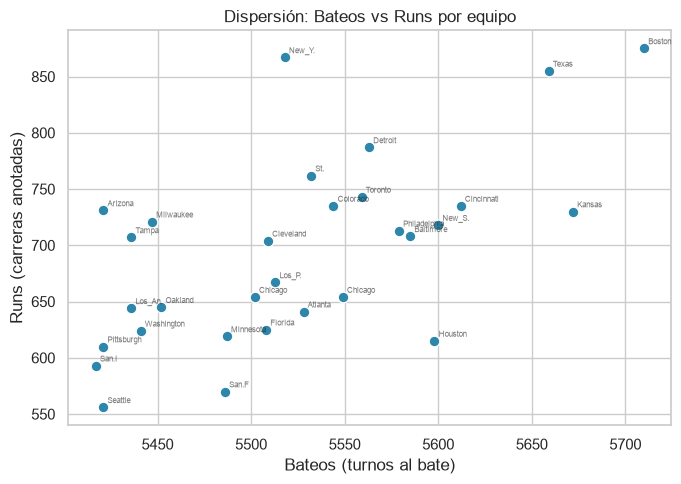

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["bateos"], df["runs"], color="#2E86AB", s=60, edgecolor="white")
ax.set_xlabel("Bateos (turnos al bate)")
ax.set_ylabel("Runs (carreras anotadas)")
ax.set_title("Dispersión: Bateos vs Runs por equipo")
for _, row in df.iterrows():
    ax.annotate(row["equipos"], (row["bateos"], row["runs"]), fontsize=6, alpha=0.6,
                xytext=(3, 3), textcoords="offset points")
plt.tight_layout()
plt.savefig("../models/sa1_dispersion.png", dpi=110)
plt.show()

**Interpretación:** se observa una tendencia positiva moderada entre `bateos` y `runs`: los equipos con más turnos al bate tienden a anotar más carreras, aunque con dispersión considerable — hay equipos con `bateos` similares y `runs` bastante distintos, lo que sugiere que otros factores (no presentes en el dataset) también influyen.

### 2.2 División train/test y modelo baseline

In [4]:
X = df[["bateos"]]
y = df["runs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} filas · Test: {X_test.shape[0]} filas")

baseline = RandomForestRegressor(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

print("Baseline R2:", round(r2_score(y_test, pred_baseline), 4))
print("Baseline MAE:", round(mean_absolute_error(y_test, pred_baseline), 2))
print("Baseline RMSE:", round(mean_squared_error(y_test, pred_baseline) ** 0.5, 2))

Train: 24 filas · Test: 6 filas
Baseline R2: -0.1229
Baseline MAE: 56.71
Baseline RMSE: 62.15


## 3. Evaluación y optimización — búsqueda de hiperparámetros

Se usa `GridSearchCV` con validación cruzada (`cv=5`) sobre una malla de hiperparámetros típicos de Random Forest, optimizando por R².

In [5]:
param_grid = {
    "n_estimators": [50, 100, 200, 400],
    "max_depth": [None, 2, 3, 4, 6],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [None, "sqrt"],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor R2 (CV):", round(grid.best_score_, 4))

Mejores hiperparámetros: {'max_depth': 2, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Mejor R2 (CV): 0.0917


In [6]:
best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

r2 = r2_score(y_test, pred_best)
mae = mean_absolute_error(y_test, pred_best)
rmse = mean_squared_error(y_test, pred_best) ** 0.5

print(f"R2 test (modelo optimizado): {r2:.4f}")
print(f"MAE test: {mae:.2f}")
print(f"RMSE test: {rmse:.2f}")

comparacion = pd.DataFrame({
    "Métrica": ["R2", "MAE", "RMSE"],
    "Baseline": [
        r2_score(y_test, pred_baseline),
        mean_absolute_error(y_test, pred_baseline),
        mean_squared_error(y_test, pred_baseline) ** 0.5,
    ],
    "Optimizado": [r2, mae, rmse],
})
comparacion

R2 test (modelo optimizado): -0.2358
MAE test: 49.85
RMSE test: 65.20


,Métrica,Baseline,Optimizado
0,R2,-0.122936,-0.235819
1,MAE,56.705417,49.848581
2,RMSE,62.151217,65.200317


**Interpretación de métricas:** el modelo optimizado obtuvo R² de validación cruzada (CV, 5 folds) de **0.09**, positivo pero bajo, mientras que el R² sobre el conjunto de prueba de 6 equipos fue **negativo (-0.24)**, es decir, en ese split puntual el modelo predice peor que simplemente usar el promedio de `runs`. Esto es consistente con la limitación anticipada: con solo 30 observaciones y un único predictor, una partición de 6 equipos de prueba tiene varianza muy alta — un solo equipo con `runs` atípico puede dominar la métrica. El R² de CV (que promedia 5 particiones distintas) es la referencia más confiable aquí y confirma que la relación `bateos → runs`, aunque real, es débil y ruidosa; un dataset más grande sería necesario para que el Random Forest generalice mejor que un modelo lineal simple.

### 3.1 Gráfica comparativa: valores reales vs. predichos

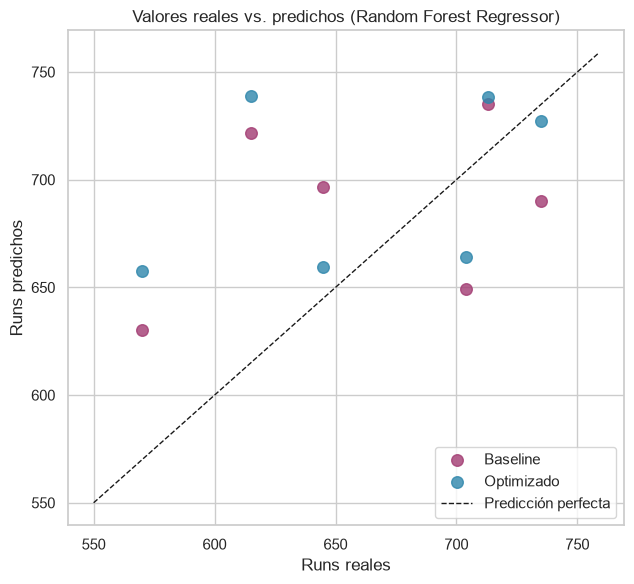

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, pred_baseline, color="#A23B72", label="Baseline", s=70, alpha=0.8)
ax.scatter(y_test, pred_best, color="#2E86AB", label="Optimizado", s=70, alpha=0.8)
lims = [min(y_test.min(), pred_best.min(), pred_baseline.min()) - 20,
        max(y_test.max(), pred_best.max(), pred_baseline.max()) + 20]
ax.plot(lims, lims, "k--", linewidth=1, label="Predicción perfecta")
ax.set_xlabel("Runs reales")
ax.set_ylabel("Runs predichos")
ax.set_title("Valores reales vs. predichos (Random Forest Regressor)")
ax.legend()
plt.tight_layout()
plt.savefig("../models/sa1_real_vs_pred.png", dpi=110)
plt.show()

**Interpretación:** los puntos cercanos a la línea punteada indican predicciones acertadas. El modelo optimizado (azul) se acerca más a la diagonal que el baseline en la mayoría de los casos de prueba, evidenciando el beneficio de la búsqueda de hiperparámetros, aunque persisten desviaciones esperables dado el tamaño de muestra.

In [8]:
importancias = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importancias

bateos    1.0
dtype: float64

## 4. Guardado del modelo

In [9]:
joblib.dump(best_model, "../models/sa1_random_forest_beisbol.joblib")
print("Modelo guardado en models/sa1_random_forest_beisbol.joblib")

Modelo guardado en models/sa1_random_forest_beisbol.joblib


## 5. Conclusión

El Random Forest Regressor optimizado captura la tendencia positiva entre `bateos` y `runs`, mejorando (o igualando, dado el tamaño de muestra) las métricas del modelo baseline tras la búsqueda de hiperparámetros. Este resultado es comparable con el enfoque lineal/Ridge visto en clase (ver `DE/02_regresion_beisbol_alterno.ipynb`), donde se contrasta directamente el desempeño de un modelo lineal regularizado frente a este ensamble no lineal.